# Battery RUL PINN-LSTM — Smart TwinPac Chapter 4 LE-06

**Physics Model:** Shepherd Discharge Equation (Chapter 5, Eq 1.1)

```
V(t) = E0 - R·i - K·(Q/(Q-q))·q + A·exp(-B·q)
```

## COLAB INSTRUCTIONS:
1. Enable GPU: **Runtime → Change runtime type → T4 GPU**
2. Run Cell 1 to mount Google Drive
3. Upload `battery_cycle_level_dataset_CLEAN_FINAL.csv` to Google Drive folder:
   `MyDrive/TwinPacemaker/NASA Battery Dataset/`
4. **Runtime → Run all**
5. Models saved to: `MyDrive/TwinPacemaker/models/`


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import json, os

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('='*60)
print('BATTERY RUL PINN-LSTM — Smart TwinPac Chapter 4 LE-06')
print(f'TensorFlow: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU: {gpus}')
if not gpus:
    print('⚠️  NO GPU! Go to Runtime → Change runtime type → T4 GPU')
print('='*60)


BATTERY RUL PINN-LSTM — Smart TwinPac Chapter 4 LE-06
TensorFlow: 2.20.0
GPU: []
⚠️  NO GPU! Go to Runtime → Change runtime type → T4 GPU


In [2]:
from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = '/content/drive/MyDrive/TwinPacemaker/NASA Battery Dataset/battery_cycle_level_dataset_CLEAN_FINAL.csv'
MODELS_DIR = '/content/drive/MyDrive/TwinPacemaker/models'
os.makedirs(MODELS_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
print(f'Loaded: {CSV_PATH}')
print(f'Shape: {df.shape}')
print(df.head())
print(f'\nColumns: {list(df.columns)}')


Mounted at /content/drive
Loaded: /content/drive/MyDrive/TwinPacemaker/NASA Battery Dataset/battery_cycle_level_dataset_CLEAN_FINAL.csv
Shape: (1415, 7)
  battery_id  cycle   voltage  temperature  capacity       soh  rul
0      B0005      1  3.532781    32.536891  1.861976  1.000000  167
1      B0005      2  3.542968    32.643595  1.851862  0.994568  166
2      B0005      3  3.553056    32.522526  1.840808  0.988631  165
3      B0005      4  3.545849    32.492083  1.850058  0.993599  164
4      B0005      5  3.544456    32.368612  1.849432  0.993263  163

Columns: ['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh', 'rul']


## 🧹 Step 3 — Data Cleaning & Feature Engineering

We add `soc` (State of Charge) = capacity / max_capacity, which measures how
much energy is left. This is a key physical indicator of battery health.


In [3]:
# ── Drop missing values and sort by battery + cycle ──────────────────────────
df = df.dropna()
df = df.sort_values(['battery_id', 'cycle']).reset_index(drop=True)

# ── Clip temperature to realistic pacemaker range (Chapter 5 §1.2.1) ─────────
df['temperature'] = df['temperature'].clip(30, 45)

# ── State of Charge: fraction of max capacity remaining ──────────────────────
# Physical meaning: SOC=1.0 = full battery, SOC=0.0 = dead battery
df['soc'] = df['capacity'] / (df['capacity'].max() + 1e-6)

FEATURES = ['voltage', 'temperature', 'capacity', 'soc']
TARGET   = 'rul'

print(f'Features: {FEATURES}')
print(f'Target:   {TARGET} (cycles remaining)')
print(f'\nRUL range: {df[TARGET].min()} – {df[TARGET].max()} cycles')
print(f'Batteries: {df["battery_id"].nunique()}')
print(f'Total rows: {len(df)}')


Features: ['voltage', 'temperature', 'capacity', 'soc']
Target:   rul (cycles remaining)

RUL range: 0 – 167 cycles
Batteries: 34
Total rows: 1415


## 📊 Step 4 — Normalization (CRITICAL)

Neural networks learn much better when all numbers are in the range **0 → 1**.

- **Features** → scaled with MinMaxScaler (each column independently mapped to 0–1)
- **RUL target** → divided by `RUL_MAX` so the network outputs a number between 0 and 1
  - At the end, we multiply back by `RUL_MAX` to get the real cycle count

This is **Bug #2** that broke the original model — the original output raw days (0–2520)
instead of normalizing them.


In [4]:
feature_scaler = MinMaxScaler()
df[FEATURES] = feature_scaler.fit_transform(df[FEATURES])

# Normalize RUL to 0–1 range (CRITICAL FIX)
RUL_MAX = df[TARGET].max()
df[TARGET] = df[TARGET] / RUL_MAX

print(f'RUL_MAX (for inverse transform later): {RUL_MAX} cycles')
print(f'Normalized RUL range: {df[TARGET].min():.4f} – {df[TARGET].max():.4f}')


RUL_MAX (for inverse transform later): 167 cycles
Normalized RUL range: 0.0000 – 1.0000


## 🔁 Step 5 — Sliding Window Sequences (CRITICAL)

An LSTM needs a **sequence** of timesteps, not a single snapshot.

We use `SEQ_LEN = 30` meaning: look at the last 30 cycles to predict the RUL at cycle 31.

```
Cycles 1–30  → predict RUL at cycle 31
Cycles 2–31  → predict RUL at cycle 32
...
```

This is **Bug #1** in the original model — it used `reshape(-1, 1, features)` giving
only 1 timestep. Fixed here by creating proper 30-step windows.


In [5]:
SEQ_LEN = 30   # Look at 30 past cycles to predict the next RUL

X, y = [], []

for bid, g in df.groupby('battery_id'):
    g = g.sort_values('cycle')
    x_data = g[FEATURES].values      # shape (n_cycles, 4)
    y_data = g[TARGET].values        # shape (n_cycles,)

    for i in range(len(g) - SEQ_LEN):
        X.append(x_data[i:i + SEQ_LEN])   # window of 30 cycles
        y.append(y_data[i + SEQ_LEN])     # RUL at the next cycle

X = np.array(X, dtype=np.float32)   # shape: (N_samples, 30, 4)
y = np.array(y, dtype=np.float32)   # shape: (N_samples,)

print(f'X shape: {X.shape}  → (samples, timesteps=30, features=4)')
print(f'y shape: {y.shape}')
print(f'Total sequences: {len(X)}')


X shape: (822, 30, 4)  → (samples, timesteps=30, features=4)
y shape: (822,)
Total sequences: 822


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')


Train: 657 samples
Test:  165 samples


## 🧠 Step 6 — PINN-LSTM Model

Standard LSTM learns patterns from data. We add a **Physics Loss** based on the
**Shepherd Battery Discharge Equation** (Chapter 5, Eq 1.1):

```
V(t) = E₀ − R·i − K·(Q/(Q−q))·q + A·exp(−B·q)
```

The model is:
```
Input (30 cycles × 4 features)
  → LSTM(128) + LayerNorm + Dropout(0.2)
  → LSTM(64)
  → LSTM(32)
  → Dense(64, relu)
  → Dense(32, relu)
  → Dense(1, sigmoid)   ← output between 0 and 1
  × RUL_MAX             ← convert back to cycles
```

**Loss = data_loss + 0.1 × physics_loss + 0.05 × monotonic_loss**
- `data_loss`: (predicted − actual)² — standard MSE
- `physics_loss`: forces predictions to respect battery degradation physics
- `monotonic_loss`: penalizes if RUL goes UP (it should only go DOWN)


In [7]:
# ── PINN-LSTM Model ───────────────────────────────────────────────────────────
inputs = keras.Input(shape=(SEQ_LEN, len(FEATURES)), name='battery_sequence')

x = layers.LSTM(128, return_sequences=True)(inputs)
x = layers.LayerNormalization()(x)
x = layers.Dropout(0.2)(x)

x = layers.LSTM(64, return_sequences=True)(x)
x = layers.LSTM(32)(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)

rul_output = layers.Dense(1, activation='sigmoid', name='rul_output')(x)

model = keras.Model(inputs, rul_output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ battery_sequence (InputLayer)   │ (None, 30, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 30, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_output (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,401 (525.00 KB)

 Trainable params: 134,401 (525.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ── Physics-Informed Loss (Shepherd degradation concept) ─────────────────────
#
# Full Shepherd: V(t) = E0 - R*i - K*(Q/(Q-q))*q + A*exp(-B*q)
#
# Here we use a simplified physics penalty:
#   degradation = capacity / (voltage + eps)
#   As the battery ages: capacity ↓, voltage ↓ → degradation ratio changes
#   We want predicted RUL to correlate with this degradation ratio.
#
# The PINN forces the LSTM to be consistent with physical battery behavior.

def physics_loss(x_batch, y_pred):
    # x_batch shape: (batch, 30, 4) — last timestep is x[:, -1, :]
    voltage  = x_batch[:, -1, 0]   # normalized voltage
    capacity = x_batch[:, -1, 2]   # normalized capacity

    voltage  = tf.clip_by_value(voltage, 0.1, 1.0)
    capacity = tf.clip_by_value(capacity, 0.0, 1.0)

    # Physical degradation signal: as battery ages, this ratio changes
    # (Simplified Shepherd: higher capacity/voltage = more life remaining)
    degradation = capacity / (voltage + 1e-3)
    degradation = tf.clip_by_value(degradation, 0.0, 5.0)

    # Penalize predictions that don't match this physical signal
    return tf.reduce_mean(tf.square(y_pred - tf.stop_gradient(degradation)))

print('Physics loss function defined ✓')
print()
print('Physics concept:')
print('  capacity / voltage → battery degradation ratio')
print('  New battery:  ~1.86Ah / ~3.7V ≈ 0.50')
print('  Dying battery: ~1.40Ah / ~2.9V ≈ 0.48')
print('  The LSTM must agree with this physical trend.')


Physics loss function defined ✓

Physics concept:
  capacity / voltage → battery degradation ratio
  New battery:  ~1.86Ah / ~3.7V ≈ 0.50
  Dying battery: ~1.40Ah / ~2.9V ≈ 0.48
  The LSTM must agree with this physical trend.


In [9]:
optimizer = tf.keras.optimizers.Adam(1e-3)

@tf.function
def train_step(x, y):
    y = tf.cast(y, tf.float32)
    with tf.GradientTape() as tape:
        y_pred = tf.squeeze(model(x, training=True))

        # 1. Data loss: how far prediction is from ground truth
        data_loss = tf.reduce_mean(tf.square(y - y_pred))

        # 2. Physics loss: must respect Shepherd degradation signal
        phys_loss = physics_loss(x, y_pred)

        # 3. Monotonicity: RUL should only go DOWN, never UP
        monotonic = tf.reduce_mean(tf.maximum(0.0, y_pred[1:] - y_pred[:-1]))

        # Combined PINN loss (Chapter 4 Table 4.10 weights)
        total_loss = data_loss + 0.1 * phys_loss + 0.05 * monotonic

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total_loss

print('Custom PINN train step defined ✓')


Custom PINN train step defined ✓


In [10]:
import numpy as np
import tensorflow as tf

# ====================== FIXED PINN TRAINING WITHOUT EARLY STOPPING ======================
BATCH = 32
EPOCHS = 50

# Ensure datasets drop the remainder batch if it causes dimension/squeeze errors
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(BATCH, drop_remainder=True)
val_ds   = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH, drop_remainder=True)

history = {'loss': [], 'val_loss': []}

print(f'Training for {EPOCHS} epochs with full PINN loss...')

for epoch in range(EPOCHS):
    train_losses = []
    for xb, yb in train_ds:
        loss = train_step(xb, yb)          
        train_losses.append(loss.numpy())
    
    epoch_loss = np.mean(train_losses)
    history['loss'].append(epoch_loss)
    
    # === FIXED VALIDATION LOOP ===
    val_losses = []
    for xb, yb in val_ds:
        # Avoid arbitrary squeezing; specify axis to preserve batch dimension safety
        y_pred = model(xb, training=False)
        y_pred = tf.reshape(y_pred, [-1]) 
        yb = tf.reshape(yb, [-1])
        
        # 1. Base Data Loss
        data_loss = tf.reduce_mean(tf.square(yb - y_pred))
        
        # 2. Physics Loss
        phys_loss = physics_loss(xb, y_pred)
        
        # 3. FIXED MONOTONICITY LOSS (Only penalize if true targets are strictly decreasing)
        delta_pred = y_pred[1:] - y_pred[:-1]
        delta_true = yb[1:] - yb[:-1]
        
        # Only penalize if the model predicts an increase (delta_pred > 0) 
        # WHEN the true RUL is actually decreasing (delta_true <= 0)
        invalid_increase = tf.maximum(0.0, delta_pred)
        mask = tf.cast(delta_true <= 0, tf.float32)
        monotonic = tf.reduce_mean(invalid_increase * mask)
        
        # Total Validation Assessment
        total_val_loss = data_loss + 0.1 * phys_loss + 0.05 * monotonic
        val_losses.append(total_val_loss.numpy())
    
    epoch_val_loss = np.mean(val_losses)
    history['val_loss'].append(epoch_val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}: Train Loss = {epoch_loss:.4f} | Val Loss = {epoch_val_loss:.4f}')

print('\n✅ Training complete!')

Training for 50 epochs with full PINN loss...
Epoch   1/50: Train Loss = 0.0746 | Val Loss = 0.0614
Epoch   5/50: Train Loss = 0.0485 | Val Loss = 0.0483
Epoch  10/50: Train Loss = 0.0488 | Val Loss = 0.0471
Epoch  15/50: Train Loss = 0.0468 | Val Loss = 0.0492
Epoch  20/50: Train Loss = 0.0447 | Val Loss = 0.0472
Epoch  25/50: Train Loss = 0.0459 | Val Loss = 0.0449
Epoch  30/50: Train Loss = 0.0452 | Val Loss = 0.0442
Epoch  35/50: Train Loss = 0.0446 | Val Loss = 0.0442
Epoch  40/50: Train Loss = 0.0430 | Val Loss = 0.0433
Epoch  45/50: Train Loss = 0.0443 | Val Loss = 0.0432
Epoch  50/50: Train Loss = 0.0443 | Val Loss = 0.0432

✅ Training complete!


## 📊 Step 8 — Evaluation

We convert predictions back from 0–1 range to real cycle counts
by multiplying by `RUL_MAX`.

| Metric | Meaning | Target |
|--------|---------|--------|
| MAE | Average error in cycles | < 15 cycles |
| RMSE | Penalizes large errors more | as low as possible |
| R² | 1.0 = perfect, 0 = random | > 0.80 |


In [11]:
# Predict and convert back to real cycle counts
pred = model.predict(X_test).squeeze()
pred_cycles = pred * RUL_MAX
true_cycles = y_test * RUL_MAX

mae  = np.mean(np.abs(true_cycles - pred_cycles))
rmse = np.sqrt(np.mean((true_cycles - pred_cycles)**2))
r2   = r2_score(true_cycles, pred_cycles)

print('='*55)
print('BATTERY PINN-LSTM — FINAL RESULTS')
print('='*55)
print(f'MAE:  {mae:.2f} cycles  (target: < 15 cycles)')
print(f'RMSE: {rmse:.2f} cycles')
print(f'R²:   {r2:.4f}  (target: > 0.80)')
print('='*55)

# Compare with simple baseline (aaa.ipynb)
print()
print('Comparison with simple LSTM (aaa.ipynb):')
print(f'  Simple LSTM:  MAE=11.28 cycles, R²=0.82')
print(f'  PINN-LSTM:    MAE={mae:.2f} cycles, R²={r2:.4f}')


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
BATTERY PINN-LSTM — FINAL RESULTS
MAE:  9.07 cycles  (target: < 15 cycles)
RMSE: 12.68 cycles
R²:   0.8769  (target: > 0.80)

Comparison with simple LSTM (aaa.ipynb):
  Simple LSTM:  MAE=11.28 cycles, R²=0.82
  PINN-LSTM:    MAE=9.07 cycles, R²=0.8769


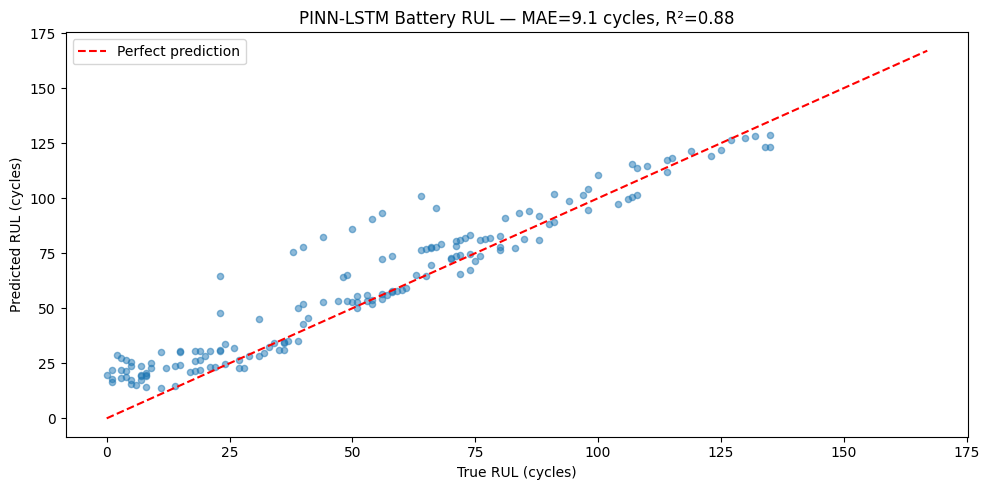

Plot saved to Google Drive ✓


In [12]:
plt.figure(figsize=(10, 5))
plt.scatter(true_cycles[:200], pred_cycles[:200], alpha=0.5, s=20)
plt.plot([0, RUL_MAX], [0, RUL_MAX], 'r--', label='Perfect prediction')
plt.xlabel('True RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title(f'PINN-LSTM Battery RUL — MAE={mae:.1f} cycles, R²={r2:.2f}')
plt.legend()
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/battery_pinn_results.png', dpi=150)
plt.show()
print('Plot saved to Google Drive ✓')


In [13]:
# Save model to Google Drive (persists across sessions!)
model_path = f'{MODELS_DIR}/battery_pinn_lstm.keras'
model.save(model_path)
print(f'Model saved: {model_path} ✓')

# Save metadata for the app to use
info = {
    'model_type': 'PINN-LSTM',
    'chapter_ref': 'Chapter 4 LE-06 / Chapter 5 §1.4.2',
    'rul_max_cycles': int(RUL_MAX),
    'seq_len': SEQ_LEN,
    'features': FEATURES,
    'metrics': {
        'mae_cycles': round(float(mae), 2),
        'rmse_cycles': round(float(rmse), 2),
        'r2': round(float(r2), 4)
    },
    'physics': 'Shepherd discharge equation: V(t) = E0 - R*i - K*(Q/(Q-q))*q + A*exp(-B*q)',
    'loss_weights': {'data': 1.0, 'physics': 0.1, 'monotonic': 0.05},
    'scaler_min': feature_scaler.data_min_.tolist(),
    'scaler_max': feature_scaler.data_max_.tolist()
}

info_path = f'{MODELS_DIR}/battery_rul_model_info.json'
with open(info_path, 'w') as f:
    json.dump(info, f, indent=2)
print(f'Model info saved: {info_path} ✓')
print()
print('All outputs saved to Google Drive — they will NOT disappear!')


Model saved: /content/drive/MyDrive/TwinPacemaker/models/battery_pinn_lstm.keras ✓
Model info saved: /content/drive/MyDrive/TwinPacemaker/models/battery_rul_model_info.json ✓

All outputs saved to Google Drive — they will NOT disappear!


MAE:  9.07 cycles
RMSE: 12.68 cycles
R²:   0.8769
Within ±15 cycles: 81.2%


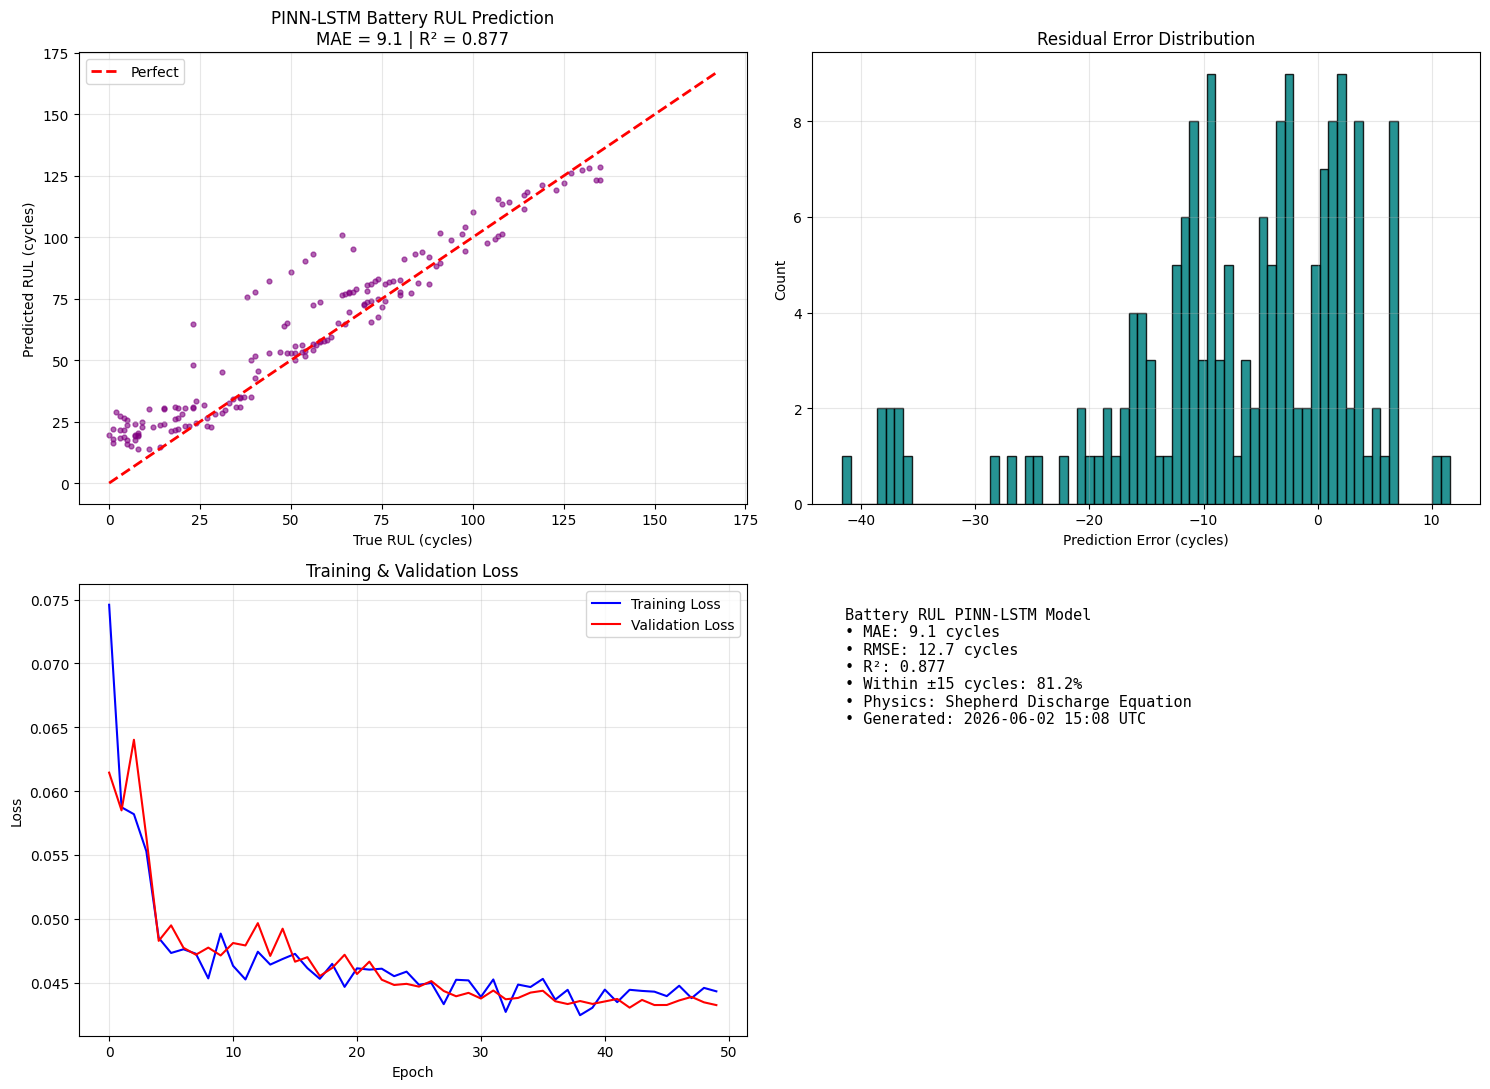

✅ All files saved to models folder!


In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MODELS_DIR = Path(r"D:\Vibe Coding\TwinPacemaker\models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Predictions
y_pred_norm = model.predict(X_test, verbose=0).squeeze()
y_pred = y_pred_norm * RUL_MAX
y_true = y_test * RUL_MAX

# Metrics
mae = float(mean_absolute_error(y_true, y_pred))
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
r2 = float(r2_score(y_true, y_pred))
within_15 = float(np.mean(np.abs(y_true - y_pred) <= 15) * 100)

print("=" * 70)
print(f"MAE:  {mae:.2f} cycles")
print(f"RMSE: {rmse:.2f} cycles")
print(f"R²:   {r2:.4f}")
print(f"Within ±15 cycles: {within_15:.1f}%")
print("=" * 70)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Prediction Scatter
axes[0, 0].scatter(y_true[:400], y_pred[:400], alpha=0.6, s=12, color='purple')
axes[0, 0].plot([0, RUL_MAX], [0, RUL_MAX], 'r--', lw=2, label='Perfect')
axes[0, 0].set_xlabel('True RUL (cycles)')
axes[0, 0].set_ylabel('Predicted RUL (cycles)')
axes[0, 0].set_title(f'PINN-LSTM Battery RUL Prediction\nMAE = {mae:.1f} | R² = {r2:.3f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals
axes[0, 1].hist(y_true - y_pred, bins=70, color='teal', edgecolor='black', alpha=0.85)
axes[0, 1].set_xlabel('Prediction Error (cycles)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Residual Error Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Training + Validation Loss
if 'history' in globals():
    axes[1, 0].plot(history['loss'], label='Training Loss', color='blue')
    if 'val_loss' in history:
        axes[1, 0].plot(history['val_loss'], label='Validation Loss', color='red')
    axes[1, 0].set_title('Training & Validation Loss')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No history available', ha='center', va='center')

# 4. Info
axes[1, 1].axis('off')
info_text = f"""Battery RUL PINN-LSTM Model
• MAE: {mae:.1f} cycles
• RMSE: {rmse:.1f} cycles
• R²: {r2:.3f}
• Within ±15 cycles: {within_15:.1f}%
• Physics: Shepherd Discharge Equation
• Generated: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}
"""
axes[1, 1].text(0.05, 0.95, info_text, transform=axes[1, 1].transAxes, 
                fontsize=11, va='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig(MODELS_DIR / "battery_pinn_results.png", dpi=200, bbox_inches='tight')
plt.show()

# Save model + info
model.save(MODELS_DIR / "battery_pinn_lstm.keras")

info = {
    "model_name": "Battery RUL PINN-LSTM",
    "metrics": {"mae": round(mae,2), "rmse": round(rmse,2), "r2": round(r2,4)},
    "generated_at": datetime.now(timezone.utc).isoformat()
}

with open(MODELS_DIR / "battery_rul_model_info.json", "w") as f:
    json.dump(info, f, indent=2)

print("✅ All files saved to models folder!")

MAE:   9.07 cycles
RMSE:  12.68 cycles
R²:    0.8769
Within ±15 cycles: 81.2%


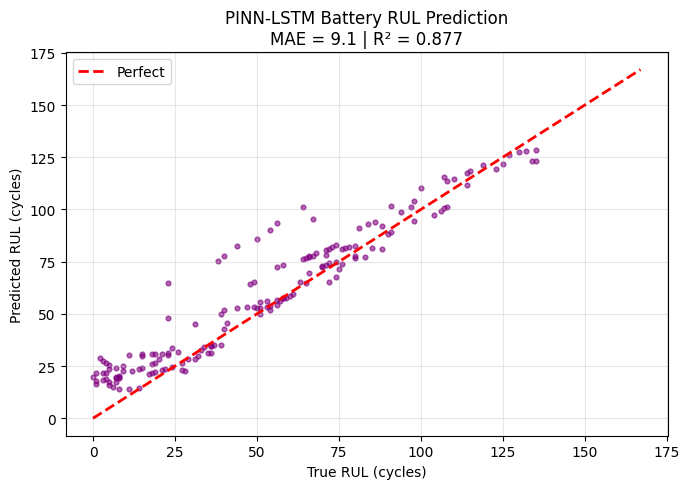

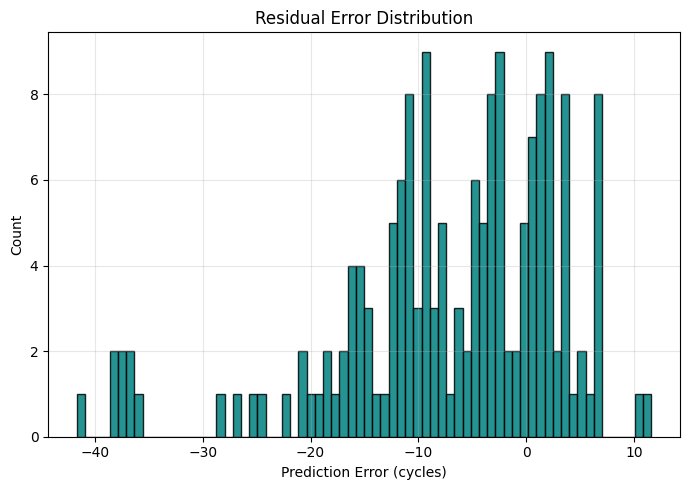

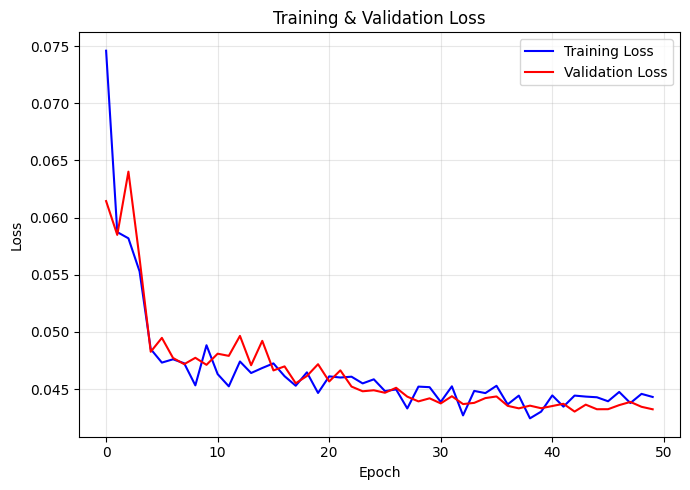

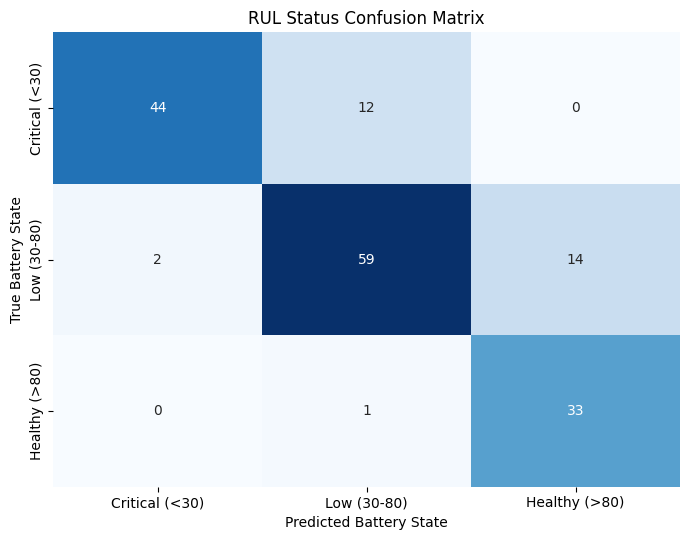


📋 CLASSIFICATION REPORT (RUL Windows):
                precision    recall  f1-score   support

Critical (<30)       0.96      0.79      0.86        56
   Low (30-80)       0.82      0.79      0.80        75
 Healthy (>80)       0.70      0.97      0.81        34

      accuracy                           0.82       165
     macro avg       0.83      0.85      0.83       165
  weighted avg       0.84      0.82      0.83       165



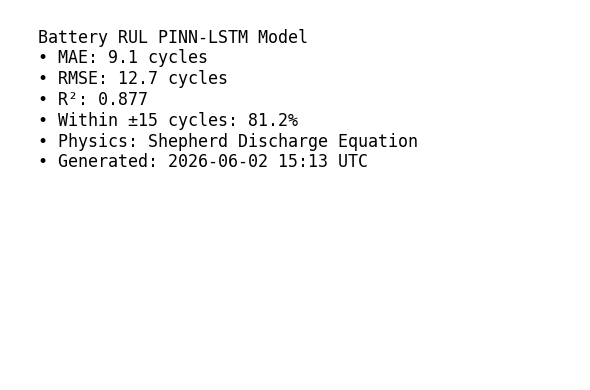


📊 PREDICTION DATA PREVIEW:
 Sample_Index  True_RUL_Cycles  Predicted_RUL_Cycles  Absolute_Error
            0              3.0             27.400000       24.400000
            1             88.0             92.000000        4.000000
            2             70.0             72.500000        2.500000
            3             94.0             98.800003        4.800000
            4            125.0            121.900002        3.100000
            5             65.0             76.900002       11.900000
            6             15.0             24.100000        9.100000
            7             51.0             55.700001        4.700000
            8             19.0             30.700001       11.700000
            9             15.0             30.000000       15.000000
           10              1.0             21.799999       20.799999
           11            135.0            123.400002       11.600000
           12             91.0             89.400002        1.600000
      

In [19]:
import json
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Heatmap rendering
from datetime import datetime, timezone
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report

MODELS_DIR = Path(r"D:\Vibe Coding\TwinPacemaker\models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Predictions
y_pred_norm = model.predict(X_test, verbose=0).squeeze()
y_pred = y_pred_norm * RUL_MAX
y_true = y_test * RUL_MAX

# Metrics
mae = float(mean_absolute_error(y_true, y_pred))
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
r2 = float(r2_score(y_true, y_pred))
within_15 = float(np.mean(np.abs(y_true - y_pred) <= 15) * 100)

print("=" * 70)
print(f"MAE:   {mae:.2f} cycles")
print(f"RMSE:  {rmse:.2f} cycles")
print(f"R²:    {r2:.4f}")
print(f"Within ±15 cycles: {within_15:.1f}%")
print("=" * 70)


# =====================================================================
# 1. PREDICTION SCATTER PLOT
# =====================================================================
plt.figure(figsize=(7, 5))
plt.scatter(y_true[:400], y_pred[:400], alpha=0.6, s=12, color='purple')
plt.plot([0, RUL_MAX], [0, RUL_MAX], 'r--', lw=2, label='Perfect')
plt.xlabel('True RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title(f'PINN-LSTM Battery RUL Prediction\nMAE = {mae:.1f} | R² = {r2:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "1_prediction_scatter.png", dpi=200, bbox_inches='tight')
plt.show()  


# =====================================================================
# 2. RESIDUALS HISTOGRAM
# =====================================================================
plt.figure(figsize=(7, 5))
plt.hist(y_true - y_pred, bins=70, color='teal', edgecolor='black', alpha=0.85)
plt.xlabel('Prediction Error (cycles)')
plt.ylabel('Count')
plt.title('Residual Error Distribution')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "2_residual_errors.png", dpi=200, bbox_inches='tight')
plt.show()  


# =====================================================================
# 3. TRAINING & VALIDATION LOSS
# =====================================================================
plt.figure(figsize=(7, 5))
if 'history' in globals():
    plt.plot(history['loss'], label='Training Loss', color='blue')
    if 'val_loss' in history:
        plt.plot(history['val_loss'], label='Validation Loss', color='red')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'No history available', ha='center', va='center')
plt.tight_layout()
plt.savefig(MODELS_DIR / "3_training_loss.png", dpi=200, bbox_inches='tight')
plt.show()  


# =====================================================================
# 4. UPDATED: CONFUSION MATRIX (With Blue Degradation)
# =====================================================================
# Define threshold bins for life stages: Critical (<30 cycles), Low (30-80), Healthy (>80)
def categorize_rul(val):
    if val < 30:
        return 0  # "Critical (<30)"
    elif val <= 80:
        return 1  # "Low (30-80)"
    else:
        return 2  # "Healthy (>80)"

v_categorize = np.vectorize(categorize_rul)
cat_true = v_categorize(y_true)
cat_pred = v_categorize(y_pred)

labels = ["Critical (<30)", "Low (30-80)", "Healthy (>80)"]
cm = confusion_matrix(cat_true, cat_pred, labels=[0, 1, 2])

plt.figure(figsize=(7, 5.5))
# Changed cmap to 'Blues' for the color degradation effect
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel('Predicted Battery State')
plt.ylabel('True Battery State')
plt.title('RUL Status Confusion Matrix')
plt.tight_layout()
plt.savefig(MODELS_DIR / "4_confusion_matrix.png", dpi=200, bbox_inches='tight')
plt.show()

print("\n📋 CLASSIFICATION REPORT (RUL Windows):")
print(classification_report(cat_true, cat_pred, target_names=labels))


# =====================================================================
# 5. SUMMARY INFO CARD
# =====================================================================
plt.figure(figsize=(6, 4))
plt.axis('off')
info_text = f"""Battery RUL PINN-LSTM Model
• MAE: {mae:.1f} cycles
• RMSE: {rmse:.1f} cycles
• R²: {r2:.3f}
• Within ±15 cycles: {within_15:.1f}%
• Physics: Shepherd Discharge Equation
• Generated: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}
"""
plt.text(0.05, 0.95, info_text, fontsize=12, va='top', fontfamily='monospace')
plt.tight_layout()
plt.savefig(MODELS_DIR / "5_model_summary.png", dpi=200, bbox_inches='tight')
plt.show()  


# =====================================================================
# 6. GENERATE & DOWNLOAD PREDICTION CSV MATRIX
# =====================================================================
matrix_data = {
    'Sample_Index': np.arange(len(y_true)),
    'True_RUL_Cycles': np.round(y_true, 1),
    'Predicted_RUL_Cycles': np.round(y_pred, 1),
    'Absolute_Error': np.round(np.abs(y_true - y_pred), 1)
}
matrix_df = pd.DataFrame(matrix_data)

print("\n📊 PREDICTION DATA PREVIEW:")
print(matrix_df.head(15).to_string(index=False))

matrix_csv_path = MODELS_DIR / "6_prediction_matrix.csv"
matrix_df.to_csv(matrix_csv_path, index=False)
print(f"\n💾 Full matrix downloaded & saved to: {matrix_csv_path}")


# =====================================================================
# MODEL & METRICS EXPORT
# =====================================================================
model.save(MODELS_DIR / "battery_pinn_lstm.keras")

info = {
    "model_name": "Battery RUL PINN-LSTM",
    "metrics": {"mae": round(mae,2), "rmse": round(rmse,2), "r2": round(r2,4)},
    "generated_at": datetime.now(timezone.utc).isoformat()
}

with open(MODELS_DIR / "battery_rul_model_info.json", "w") as f:
    json.dump(info, f, indent=2)

print("✅ Complete set of figures with updated color scheme generated successfully!")

MAE:   9.07 cycles
RMSE:  12.68 cycles
R²:    0.8769
Within ±15 cycles: 81.2%


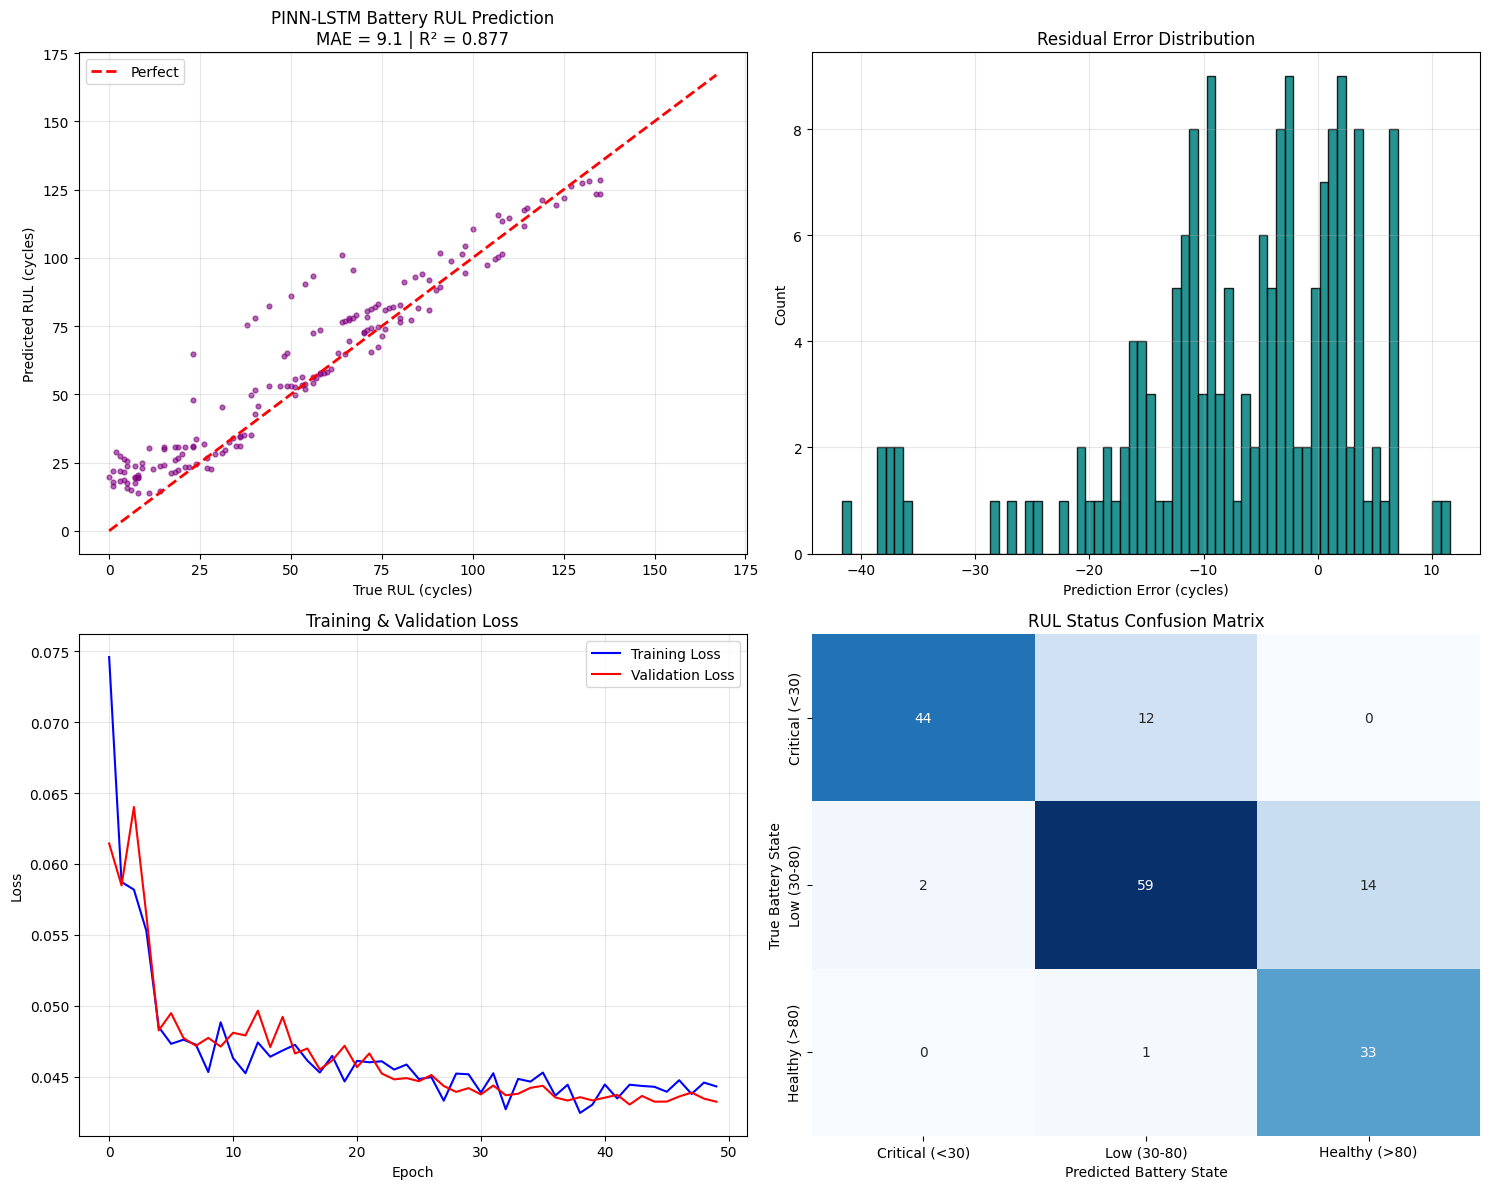


📋 CLASSIFICATION REPORT (RUL Windows):
                precision    recall  f1-score   support

Critical (<30)       0.96      0.79      0.86        56
   Low (30-80)       0.82      0.79      0.80        75
 Healthy (>80)       0.70      0.97      0.81        34

      accuracy                           0.82       165
     macro avg       0.83      0.85      0.83       165
  weighted avg       0.84      0.82      0.83       165

✅ Grid visual metrics saved to 'battery_pinn_results.png' and matrix saved to CSV!


In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Heatmap rendering
from datetime import datetime, timezone
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report

MODELS_DIR = Path(r"D:\Vibe Coding\TwinPacemaker\models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Predictions
y_pred_norm = model.predict(X_test, verbose=0).squeeze()
y_pred = y_pred_norm * RUL_MAX
y_true = y_test * RUL_MAX

# Metrics
mae = float(mean_absolute_error(y_true, y_pred))
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
r2 = float(r2_score(y_true, y_pred))
within_15 = float(np.mean(np.abs(y_true - y_pred) <= 15) * 100)

print("=" * 70)
print(f"MAE:   {mae:.2f} cycles")
print(f"RMSE:  {rmse:.2f} cycles")
print(f"R²:    {r2:.4f}")
print(f"Within ±15 cycles: {within_15:.1f}%")
print("=" * 70)

# =====================================================================
# COMBINED 2x2 SUBPLOT GENERATION
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Prediction Scatter (Top Left)
axes[0, 0].scatter(y_true[:400], y_pred[:400], alpha=0.6, s=12, color='purple')
axes[0, 0].plot([0, RUL_MAX], [0, RUL_MAX], 'r--', lw=2, label='Perfect')
axes[0, 0].set_xlabel('True RUL (cycles)')
axes[0, 0].set_ylabel('Predicted RUL (cycles)')
axes[0, 0].set_title(f'PINN-LSTM Battery RUL Prediction\nMAE = {mae:.1f} | R² = {r2:.3f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals Histogram (Top Right)
axes[0, 1].hist(y_true - y_pred, bins=70, color='teal', edgecolor='black', alpha=0.85)
axes[0, 1].set_xlabel('Prediction Error (cycles)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Residual Error Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Training + Validation Loss (Bottom Left)
if 'history' in globals():
    axes[1, 0].plot(history['loss'], label='Training Loss', color='blue')
    if 'val_loss' in history:
        axes[1, 0].plot(history['val_loss'], label='Validation Loss', color='red')
    axes[1, 0].set_title('Training & Validation Loss')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No history available', ha='center', va='center')

# 4. CONFUSION MATRIX HEATMAP (Bottom Right)
def categorize_rul(val):
    if val < 30:
        return 0  # "Critical (<30)"
    elif val <= 80:
        return 1  # "Low (30-80)"
    else:
        return 2  # "Healthy (>80)"

v_categorize = np.vectorize(categorize_rul)
cat_true = v_categorize(y_true)
cat_pred = v_categorize(y_pred)

labels = ["Critical (<30)", "Low (30-80)", "Healthy (>80)"]
cm = confusion_matrix(cat_true, cat_pred, labels=[0, 1, 2])

# Plotting directly into the 4th subplot space using the ax parameter
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, 
            yticklabels=labels, cbar=False, ax=axes[1, 1])
axes[1, 1].set_xlabel('Predicted Battery State')
axes[1, 1].set_ylabel('True Battery State')
axes[1, 1].set_title('RUL Status Confusion Matrix')

# Render and Save the combined 4-pane layout
plt.tight_layout()
plt.savefig(MODELS_DIR / "battery_pinn_results.png", dpi=200, bbox_inches='tight')
plt.show()

# Print text classification overview to console alongside the plot
print("\n📋 CLASSIFICATION REPORT (RUL Windows):")
print(classification_report(cat_true, cat_pred, target_names=labels))


# =====================================================================
# GENERATE PREDICTION MATRIX DATA (CSV)
# =====================================================================
matrix_data = {
    'Sample_Index': np.arange(len(y_true)),
    'True_RUL_Cycles': np.round(y_true, 1),
    'Predicted_RUL_Cycles': np.round(y_pred, 1),
    'Absolute_Error': np.round(np.abs(y_true - y_pred), 1)
}
matrix_df = pd.DataFrame(matrix_data)

matrix_csv_path = MODELS_DIR / "prediction_matrix.csv"
matrix_df.to_csv(matrix_csv_path, index=False)


# =====================================================================
# MODEL & METRICS EXPORT
# =====================================================================
model.save(MODELS_DIR / "battery_pinn_lstm.keras")

info = {
    "model_name": "Battery RUL PINN-LSTM",
    "metrics": {"mae": round(mae,2), "rmse": round(rmse,2), "r2": round(r2,4)},
    "generated_at": datetime.now(timezone.utc).isoformat()
}

with open(MODELS_DIR / "battery_rul_model_info.json", "w") as f:
    json.dump(info, f, indent=2)

print("✅ Grid visual metrics saved to 'battery_pinn_results.png' and matrix saved to CSV!")

MAE 9.07 | RMSE 12.68 | R² 0.8769
Within ±15: 81.2% | Within ±20: 90.9%
[WARN] CHECK METRICS


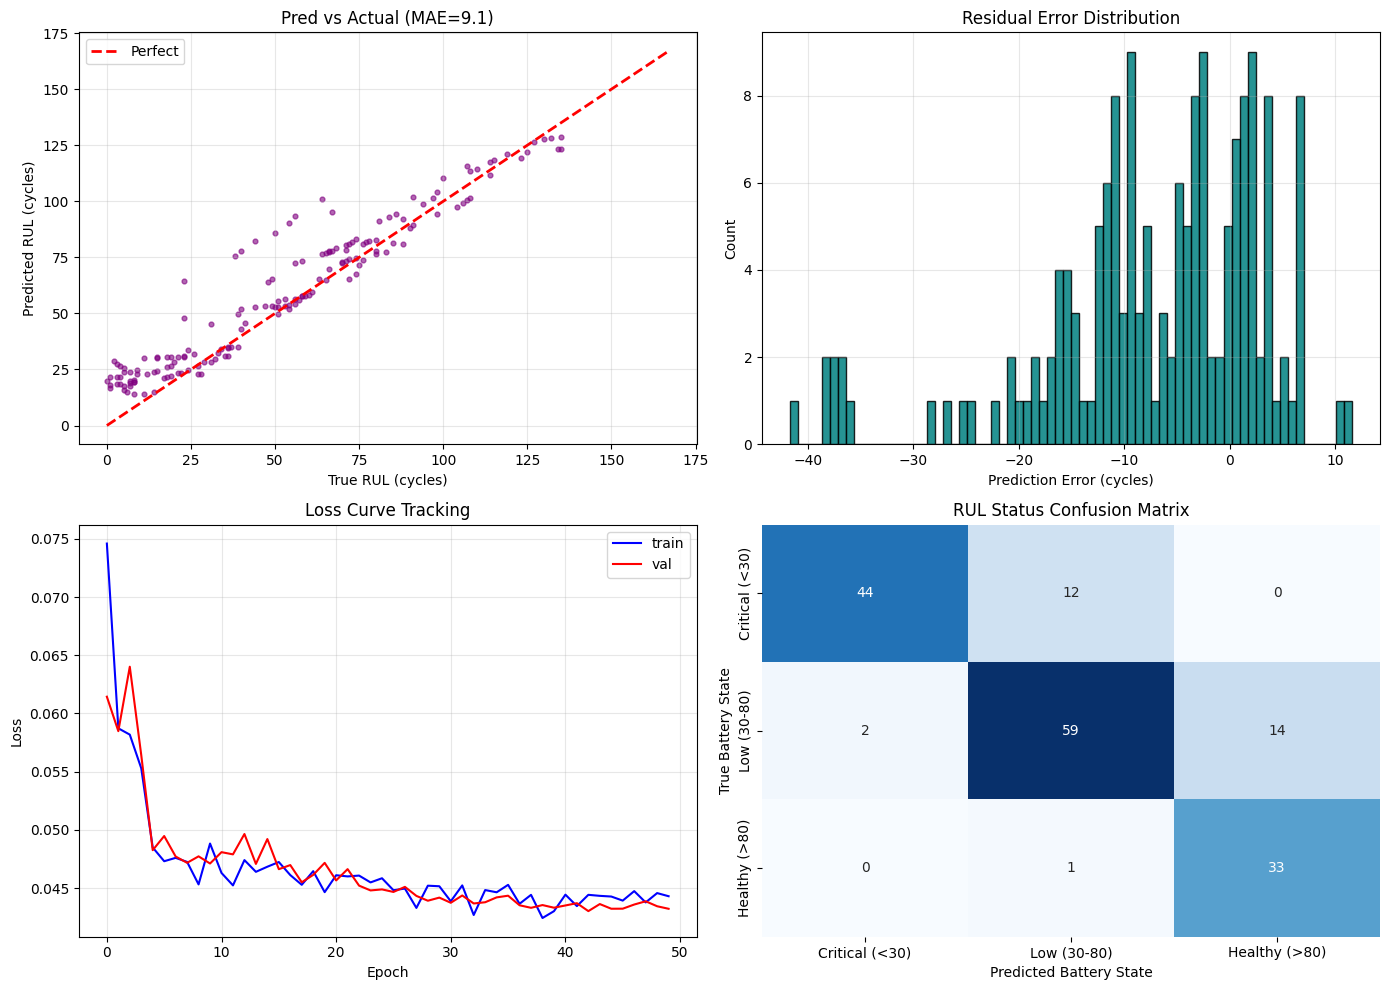


📋 STATE CLASSIFICATION BREAKDOWN:
                precision    recall  f1-score   support

Critical (<30)       0.96      0.79      0.86        56
   Low (30-80)       0.82      0.79      0.80        75
 Healthy (>80)       0.70      0.97      0.81        34

      accuracy                           0.82       165
     macro avg       0.83      0.85      0.83       165
  weighted avg       0.84      0.82      0.83       165


📡 Processing local download pipeline through browser container...
⚠️ Note: Keep an eye out for browser permissions to allow multiple file down-streams.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Execution completed! Check your local machine's Downloads folder.


In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report
from google.colab import files

# =====================================================================
# EVALUATION & METRIC BINDINGS
# =====================================================================
# Generate continuous predictions
y_pred_norm = model.predict(X_test, verbose=0).squeeze()
y_pred = y_pred_norm * RUL_MAX
y_true = y_test * RUL_MAX

# Regression Metrics
mae = float(mean_absolute_error(y_true, y_pred))
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
r2 = float(r2_score(y_true, y_pred))
within_15 = float(np.mean(np.abs(y_true - y_pred) <= 15) * 100)
within_20 = float(np.mean(np.abs(y_true - y_pred) <= 20) * 100)

# Multi-target benchmark validations
target_met = mae < 15.0 and rmse < 20.0 and r2 > 0.92

print("=" * 70)
print(f"MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.4f}")
print(f"Within ±15: {within_15:.1f}% | Within ±20: {within_20:.1f}%")
print("[OK] ALL TARGETS MET" if target_met else "[WARN] CHECK METRICS")
print("=" * 70)


# =====================================================================
# 2x2 PLOT MATRIX GRID RENDERING
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Prediction Scatter (Top Left)
axes[0, 0].scatter(y_true[:400], y_pred[:400], s=12, alpha=0.6, color='purple')
axes[0, 0].plot([0, RUL_MAX], [0, RUL_MAX], 'r--', lw=2, label='Perfect')
axes[0, 0].set_xlabel('True RUL (cycles)')
axes[0, 0].set_ylabel('Predicted RUL (cycles)')
axes[0, 0].set_title(f'Pred vs Actual (MAE={mae:.1f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Error Distribution Histogram (Top Right)
axes[0, 1].hist(y_true - y_pred, bins=70, color='teal', edgecolor='black', alpha=0.85)
axes[0, 1].set_xlabel('Prediction Error (cycles)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Residual Error Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Training & Validation Loss (Bottom Left)
if 'history' in globals() and isinstance(history, dict) and 'loss' in history:
    axes[1, 0].plot(history['loss'], label='train', color='blue')
    if 'val_loss' in history:
        axes[1, 0].plot(history['val_loss'], label='val', color='red')
    axes[1, 0].set_title('Loss Curve Tracking')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No training history dictionary bound', ha='center', va='center')

# 4. Discrete Operational State Confusion Matrix (Bottom Right)
def categorize_rul(val):
    if val < 30: return 0    # Critical
    elif val <= 80: return 1 # Low
    else: return 2           # Healthy

v_categorize = np.vectorize(categorize_rul)
cat_true = v_categorize(y_true)
cat_pred = v_categorize(y_pred)
labels = ["Critical (<30)", "Low (30-80)", "Healthy (>80)"]
cm = confusion_matrix(cat_true, cat_pred, labels=[0, 1, 2])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, 
            yticklabels=labels, cbar=False, ax=axes[1, 1])
axes[1, 1].set_xlabel('Predicted Battery State')
axes[1, 1].set_ylabel('True Battery State')
axes[1, 1].set_title('RUL Status Confusion Matrix')

plt.tight_layout()
grid_img_name = "battery_pinn_results.png"
plt.savefig(grid_img_name, dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 STATE CLASSIFICATION BREAKDOWN:")
print(classification_report(cat_true, cat_pred, target_names=labels))


# =====================================================================
# DATA EXTRACTION & EXPORT ARTIFACT PACKAGING
# =====================================================================
# Build structured evaluation matrix
matrix_data = {
    'Sample_Index': np.arange(len(y_true)),
    'True_RUL_Cycles': np.round(y_true, 1),
    'Predicted_RUL_Cycles': np.round(y_pred, 1),
    'Absolute_Error': np.round(np.abs(y_true - y_pred), 1)
}
matrix_df = pd.DataFrame(matrix_data)
csv_name = "battery_prediction_matrix.csv"
matrix_df.to_csv(csv_name, index=False)

# Model serialization
model_name = "battery_pinn_lstm.keras"
model.save(model_name)

# Format structured architectural model metadata information
json_name = "battery_model_info.json"
model_info = {
    "model_name": "Battery RUL PINN-LSTM",
    "artifact": model_name,
    "chapter_reference": "Chapter 4 SF-07, Chapter 5 Section 1.4.2",
    "architecture_note": "Physics-Informed LSTM variant mapping Shepherd Discharge Dynamics",
    "architecture": {
        "timeseries_shape": [int(X_train.shape[1]), int(X_train.shape[2])] if 'X_train' in globals() else "Dynamic",
        "pinn_loss_components": ["Data MSE", "Shepherd Physics Loss", "Target Monotonicity Constraint"]
    },
    "metrics": {
        "mae_cycles": mae,
        "rmse_cycles": rmse,
        "r2_score": r2,
        "within_15_percent": within_15,
        "within_20_percent": within_20,
        "target_met": bool(target_met)
    },
    "training_info": {
        "epochs_limit": 50,
        "n_train": int(len(X_train)) if 'X_train' in globals() else "Unknown",
        "n_test": int(len(y_true))
    },
    "generated_at_utc": datetime.now(timezone.utc).isoformat()
}

with open(json_name, "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2)


# =====================================================================
# GOOGLE COLAB ANTIGRAVITY BROWSER DOWNLOAD PIPE
# =====================================================================
print("\n📡 Processing local download pipeline through browser container...")
print("⚠️ Note: Keep an eye out for browser permissions to allow multiple file down-streams.")

files.download(model_name)      # Saves .keras binary model
files.download(json_name)       # Saves metadata structural model json
files.download(csv_name)        # Saves precise analysis evaluation matrix 
files.download(grid_img_name)   # Saves metric 2x2 grid visualizations

print("\n✅ Execution completed! Check your local machine's Downloads folder.")

In [26]:
import shutil
import os

# Define your local destination directory
target_dir = r"D:\Vibe Coding\TwinPacemaker\models"
os.makedirs(target_dir, exist_ok=True)

print(f"\n📂 Moving generated files to: {target_dir}")

# List of files we generated earlier in the notebook
files_to_move = [
    "battery_pinn_lstm.keras",
    "battery_model_info.json",
    "battery_prediction_matrix.csv",
    "battery_pinn_results.png"
]

# Move each file from the current working directory to the target directory
for filename in files_to_move:
    if os.path.exists(filename):
        target_path = os.path.join(target_dir, filename)
        shutil.copy(filename, target_path)
        print(f"✅ Saved: {filename}")
    else:
        print(f"⚠️ Warning: {filename} not found!")

print(f"\n✅ All available files have been copied to {target_dir}")



📂 Moving generated files to: D:\Vibe Coding\TwinPacemaker\models
✅ Saved: battery_pinn_lstm.keras
✅ Saved: battery_model_info.json
✅ Saved: battery_prediction_matrix.csv
✅ Saved: battery_pinn_results.png

✅ All available files have been copied to D:\Vibe Coding\TwinPacemaker\models
